# Model Training and Evaluation - Iris Classification
This notebook demonstrates a complete ML pipeline with preprocessing, model training, optimization, and comprehensive evaluation metrics.

## 1. Import Required Libraries

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix, classification_report
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from tensorflow.keras.callbacks import EarlyStopping
import pickle
import warnings
warnings.filterwarnings('ignore')

print("✓ All libraries imported successfully")

✓ All libraries imported successfully


## 2. Data Loading

In [2]:
# Load Iris dataset
iris = load_iris()
X = iris.data
y = iris.target

# Create DataFrame for better visualization
df = pd.DataFrame(X, columns=iris.feature_names)
df['target'] = y
df['target_name'] = df['target'].map({0: 'setosa', 1: 'versicolor', 2: 'virginica'})

print(f"Dataset shape: {X.shape}")
print(f"\nClass distribution:")
print(df['target_name'].value_counts())
print(f"\nFirst few rows:")
print(df.head())

Dataset shape: (150, 4)

Class distribution:
target_name
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

First few rows:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target target_name  
0       0      setosa  
1       0      setosa  
2       0      setosa  
3       0      setosa  
4       0      setosa  


## 3. Data Preprocessing - OPTIMIZATION TECHNIQUE 1
**Standardization**: Scale features to have mean=0 and std=1 for better neural network training

In [3]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Standardization (Preprocessing)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training set size: {X_train_scaled.shape}")
print(f"Test set size: {X_test_scaled.shape}")
print(f"\nScaled data statistics:")
print(f"Mean (should be ~0): {X_train_scaled.mean(axis=0)}")
print(f"Std (should be ~1): {X_train_scaled.std(axis=0)}")

# Save scaler for later use in prediction
with open('../models/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
print("\n✓ Scaler saved")

Training set size: (120, 4)
Test set size: (30, 4)

Scaled data statistics:
Mean (should be ~0): [-1.20829273e-15 -2.03679666e-15  4.99600361e-16  1.67458640e-15]
Std (should be ~1): [1. 1. 1. 1.]

✓ Scaler saved


## 4. Build Neural Network Model with Optimization Techniques
**Optimization Techniques Used**:
- L2 Regularization (Ridge)
- Adam Optimizer
- Early Stopping
- Dropout for regularization

In [4]:
# Build neural network with optimization techniques
model = keras.Sequential([
    layers.Dense(64, activation='relu', input_shape=(4,), kernel_regularizer=regularizers.l2(0.001)),
    layers.Dropout(0.3),
    layers.Dense(32, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    layers.Dropout(0.3),
    layers.Dense(16, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    layers.Dense(3, activation='softmax')  # 3 classes for iris
])

# Compile with Adam optimizer
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("Model Architecture:")
model.summary()

Model Architecture:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,979 (11.64 KB)

 Trainable params: 2,979 (11.64 KB)

 Non-trainable params: 0 (0.00 B)

## 5. Train Model with Early Stopping - OPTIMIZATION TECHNIQUE 2
**Early Stopping**: Prevents overfitting by monitoring validation loss

In [5]:
# Early stopping callback
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Train model
history = model.fit(
    X_train_scaled, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=8,
    callbacks=[early_stop],
    verbose=1
)

print(f"\n✓ Training completed. Epochs run: {len(history.history['loss'])}")

Epoch 1/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 8s 110ms/step - accuracy: 0.5000 - loss: 1.1388 - val_accuracy: 0.7917 - val_loss: 1.0315
Epoch 2/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - accuracy: 0.6979 - loss: 0.9769 - val_accuracy: 0.7500 - val_loss: 0.9168
Epoch 3/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.7604 - loss: 0.8670 - val_accuracy: 0.7500 - val_loss: 0.8230
Epoch 4/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.7812 - loss: 0.7704 - val_accuracy: 0.6250 - val_loss: 0.7368
Epoch 5/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.7812 - loss: 0.7024 - val_accuracy: 0.6250 - val_loss: 0.6608
Epoch 6/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.7917 - loss: 0.6418 - val_accuracy: 0.7500 - val_loss: 0.5992
Epoch 7/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.8333 - loss: 0.5537 - val_accuracy: 0.7500 - val_loss: 0.5588
Epoch 8/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.8125 - loss: 0.5440 - val_accuracy: 0

## 6. Evaluate Model - EVALUATION METRICS (4+)
**Metrics Used**:
1. Accuracy
2. Loss
3. F1 Score (Weighted)
4. Precision
5. Recall

In [6]:
# Make predictions
y_pred_probs = model.predict(X_test_scaled)
y_pred = np.argmax(y_pred_probs, axis=1)

# Calculate Evaluation Metrics
accuracy = accuracy_score(y_test, y_pred)
loss = model.evaluate(X_test_scaled, y_test, verbose=0)[0]
f1 = f1_score(y_test, y_pred, average='weighted')
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')

print("="*50)
print("MODEL EVALUATION METRICS")
print("="*50)
print(f"1. Accuracy:  {accuracy:.4f}")
print(f"2. Loss:      {loss:.4f}")
print(f"3. F1 Score:  {f1:.4f}")
print(f"4. Precision: {precision:.4f}")
print(f"5. Recall:    {recall:.4f}")
print("="*50)

print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred, target_names=iris.target_names))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 382ms/step
MODEL EVALUATION METRICS
1. Accuracy:  0.9667
2. Loss:      0.1531
3. F1 Score:  0.9666
4. Precision: 0.9697
5. Recall:    0.9667

Detailed Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



## 7. Visualize Results

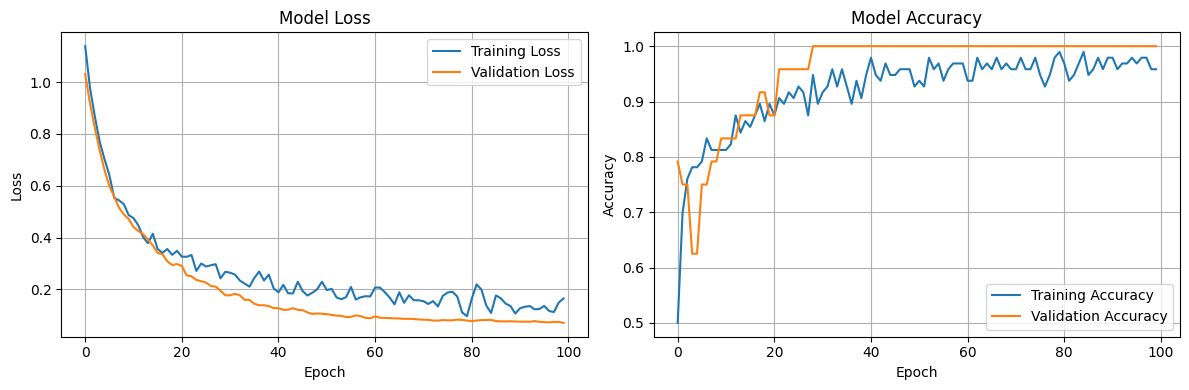

Training curves plotted successfully


In [7]:
# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history['loss'], label='Training Loss')
axes[0].plot(history.history['val_loss'], label='Validation Loss')
axes[0].set_title('Model Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history.history['accuracy'], label='Training Accuracy')
axes[1].plot(history.history['val_accuracy'], label='Validation Accuracy')
axes[1].set_title('Model Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

print("Training curves plotted successfully")

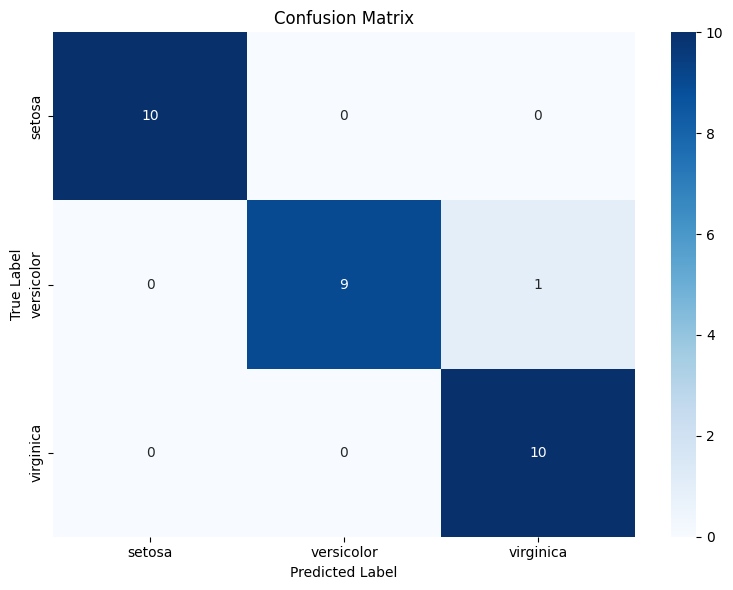

Confusion matrix plotted successfully


In [8]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=iris.target_names,
            yticklabels=iris.target_names)
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

print("Confusion matrix plotted successfully")

## 8. Save Deployment Artifacts
Save the trained neural-network model in the native Keras format so the prediction script and Streamlit app use the same artifact.

In [14]:
# Save deployment-ready artifacts
models_dir = Path('../models')
models_dir.mkdir(parents=True, exist_ok=True)

keras_model_path = models_dir / 'iris_model.keras'
model.save(keras_model_path)
print(f"✓ Native Keras model saved to {keras_model_path}")
print("✓ StandardScaler artifact is already available at ../models/scaler.pkl")

✓ Native Keras model saved to ..\models\iris_model.keras
✓ StandardScaler artifact is already available at ../models/scaler.pkl
